In [1]:
import collections
import matplotlib.pyplot as plt
from IPython import display
import numpy as np
import math

import copy
import torch
from torch import Tensor, nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

from common.const import DATASET_PATH
from common.util import *
from common.meta import MetaData
from common.optimise_v4 import NetLineStepProcessor

from torchvision.datasets import CIFAR100
from torchvision import transforms

import logging

In [2]:
logging.basicConfig(filename="log_convcrity_cifar100_epochsd_v3.log",
                level=logging.INFO,
                format="%(levelname)s: %(asctime)s %(message)s")


#### CIFAR100 dataset

In [3]:
# Convert from PIL to torch.Tensort
# and normalize each pixel from [0, 255] range to [0.0, 1.0]
base_transforms = transforms.ToTensor()

# An augmentation that randomly (with a probability equal to 0.5)
# flips the image horizontally
# This will prevent overfitting and make the model more robust
aug_transforms = transforms.RandomHorizontalFlip(p=0.5)

# Gather all transforms together
train_transforms = transforms.Compose([
    base_transforms,
    aug_transforms
])

train_dataset = CIFAR100(root=DATASET_PATH, train=True, download=True, transform=train_transforms)

# Note that we only use `base_transforms` for test dataset
test_dataset = CIFAR100(root=DATASET_PATH, train=False, download=True, transform=base_transforms)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
BATCH_SIZE = 128 #128 #32 #64 #32

# `pin_memory` speed up processing if you use GPU
# `num_workers` also speed up processing since use additional process
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                             num_workers=0, pin_memory=True)

In [5]:
#Weights distribution variances are set as in (5.67)
slope_plus, slope_minus=1.0, 0.1
cb, cw = 0, 2.0/(slope_plus**2.0 + slope_minus**2.0)

INPUT_DIM=32*32 #*3 USING 0.299 ∙ Red + 0.587 ∙ Green + 0.114 ∙ Blue for gray-transform
OUTPUT_DIM = 100 #26  # num of classes

lb, lw = 0.005, 5.0
meta = MetaData(input_dim = INPUT_DIM, output_dim = OUTPUT_DIM, batch_size = BATCH_SIZE, lb = 0.005, lw = 5.0)

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


##### UTILS

#### Compare optimisers

In [6]:
def print_comparison(HISTORY_NORM2, HISTORY_OPTFIX, HISTORY_ADAM):
    #start_epoch, finish_epoch = 10, 20
    display.clear_output()
    fig, axes = plt.subplots(2, 1, figsize=(12, 16))
    axes[0].set_title('Loss (Cross Entropy)')
    #axes[0].set_xlim(start_epoch-1, finish_epoch)
    #axes[0].plot(HISTORY_NORM1['train_loss'][2:40], color='g', ls='dotted', alpha=.5, label='Train norm1')
    #axes[0].plot(HISTORY_NORM2['train_loss'][2:40], color='b', ls='dotted', alpha=.5, label='Train norm2')
    #axes[0].plot(HISTORY_ZHS['train_loss'][2:40], color='r', ls='dotted', alpha=.5, label='Train Zhang-simple')
    #axes[0].plot(HISTORY_ZHL['train_loss'][2:40], color='orange', ls='dotted', alpha=.5, label='Train Zhang-lambda')
    #axes[0].plot(HISTORY_OPTADA['train_loss'][2:40], color='brown', ls='dotted', alpha=.5, label='Train direct Zhang-lambda')
    axes[0].plot(HISTORY_ADAM['test_loss'], color='g', alpha=.5, label='Adam')
    axes[0].plot(HISTORY_NORM2['test_loss'], color='b', alpha=.5, label='Net-line')
    #axes[0].plot(HISTORY_ZHS['test_loss'], color='r', alpha=.5, label='Test Zhang-simple')
    #axes[0].plot(HISTORY_ZHL['test_loss'], color='orange', alpha=.5, label='Test Zhang-lambda')
    #axes[0].plot(HISTORY_OPTADA['test_loss'], color='purple', alpha=.5, label='Test Zhang-simple optimiser')
    axes[0].plot(HISTORY_OPTFIX['test_loss'], color='grey', alpha=.5, label='SGD')
    axes[0].grid()
    axes[0].legend()
    axes[0].set_xlabel("Epoch (series of gradient descent steps)")
    axes[0].set_ylabel("Loss value")

    axes[1].set_title('Accuracy')
    #axes[1].set_xlim(10, 20)
    #axes[1].plot(HISTORY_NORM1['train_accuracy'][2:40], color='g', alpha=.5, ls='dotted', label='Train norm1')
    #axes[1].plot(HISTORY_NORM2['train_accuracy'][2:40], color='b', alpha=.5, ls='dotted', label='Train norm2')
    #axes[1].plot(HISTORY_ZHS['train_accuracy'][2:40], color='r', alpha=.5, ls='dotted', label='Train Zhang-simple')
    #axes[1].plot(HISTORY_ZHL['train_accuracy'][2:40], color='orange', alpha=.5, ls='dotted', label='Train Zhang-lambda')
    #axes[1].plot(HISTORY_OPTADA['train_accuracy'][2:40], color='brown', alpha=.5, ls='dotted', label='Train direct Zhang-lambda')
    axes[1].plot(HISTORY_ADAM['test_accuracy'], color='g', alpha=.5, label='Adam')
    axes[1].plot(HISTORY_NORM2['test_accuracy'], color='b', alpha=.5, label='Net-line')
    #axes[1].plot(HISTORY_ZHS['test_accuracy'], color='r', alpha=.5, label='Test Zhang-simple')
    #axes[1].plot(HISTORY_ZHL['test_accuracy'], color='orange', alpha=.5, label='Test Zhang-lambda')
    #axes[1].plot(HISTORY_OPTADA['test_accuracy'], color='purple', alpha=.5, label='Test Zhang-simple optimiser')
    axes[1].plot(HISTORY_OPTFIX['test_accuracy'], color='grey', alpha=.5, label='SGD')
    axes[1].grid()
    axes[1].legend()
    axes[1].set_xlabel("Epoch (series of gradient descent steps)")
    axes[1].set_ylabel("Accuracy value")

    #fig.tight_layout()
    #fig.subplots_adjust(top=0.95)
    dummy=fig.suptitle("Comparison for the same CNN architecture for different optimisers")

    plt.show()

#### Reference CNN

In [7]:
def make_model():
    
    model = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=16, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.MaxPool2d(kernel_size = (2,2)),
        nn.Dropout(0.25),
        nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.MaxPool2d(kernel_size = (2,2)),
        nn.Dropout(0.25),
        nn.Flatten(),
        nn.Linear(4096, 512),
        nn.LeakyReLU(0.1),
        nn.Dropout(0.5),
        nn.Linear(512, 100)
    )

    return model

In [8]:
#HISTORY_NORM1 = collections.defaultdict(list)
HISTORY_NORM2 = collections.defaultdict(list)
HISTORY_OPTFIX = collections.defaultdict(list)
HISTORY_ADAM = collections.defaultdict(list)


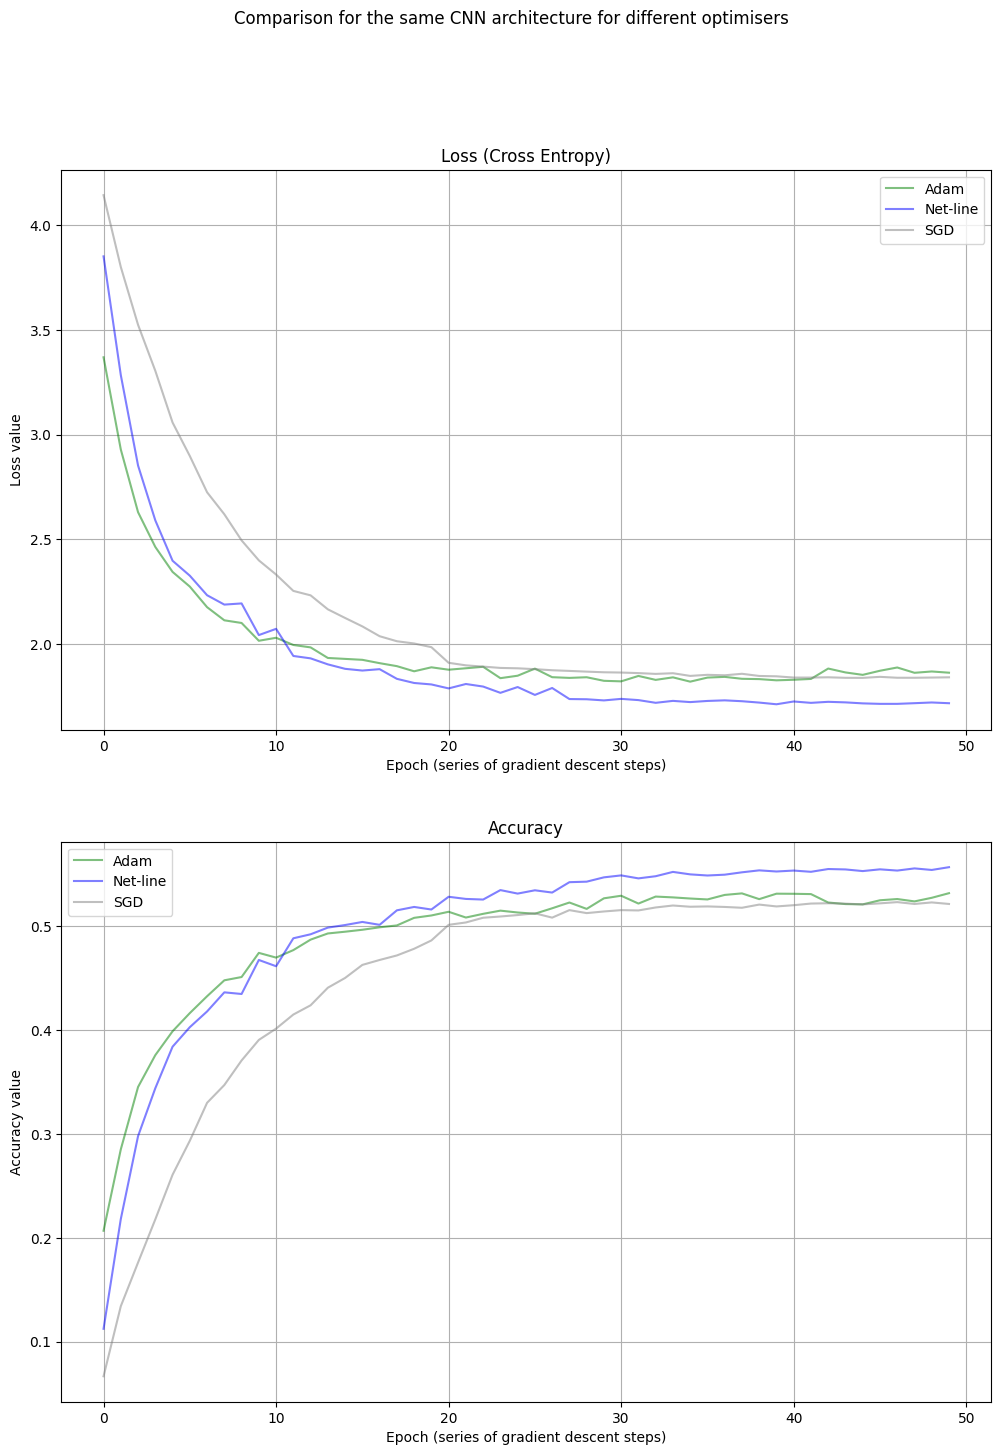

accuracy norm2=[0.11244066455696203, 0.21805775316455697, 0.2978639240506329, 0.34394778481012656, 0.3839003164556962, 0.4026898734177215, 0.41782041139240506, 0.4362143987341772, 0.43463212025316456, 0.46736550632911394, 0.46133306962025317, 0.48823180379746833, 0.4920886075949367, 0.4985166139240506, 0.5009889240506329, 0.5039556962025317, 0.5011867088607594, 0.5151305379746836, 0.5183939873417721, 0.5159216772151899, 0.528184335443038, 0.5261075949367089, 0.5255142405063291, 0.5346123417721519, 0.53125, 0.5344145569620253, 0.5322389240506329, 0.5422270569620253, 0.5427215189873418, 0.546875, 0.5487539556962026, 0.5458860759493671, 0.5479628164556962, 0.5521162974683544, 0.5497428797468354, 0.5486550632911392, 0.5494462025316456, 0.5517207278481012, 0.5535996835443038, 0.5525118670886076, 0.5534018987341772, 0.5522151898734177, 0.5548852848101266, 0.5544897151898734, 0.5529074367088608, 0.5545886075949367, 0.5534018987341772, 0.5554786392405063, 0.553995253164557, 0.5566653481012658]

In [9]:
def test_loop(testNet):
    test_loss_meter, test_accuracy_meter = AverageMeter(), AverageMeter(),
    for test_batch in test_dataloader:
        images, labels = test_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        with torch.no_grad():
            logits = testNet.forward(images)

            zz_logits = np.transpose(logits.detach().cpu().numpy())
            prediction = logits.argmax(dim=-1).detach()
            loss = loss_crossentropy(zz_logits, labels)
            test_loss_meter.update(loss)
            test_accuracy_meter.update(calculate_accuracy(prediction, labels))

    return test_loss_meter.avg, test_accuracy_meter.avg


NUM_EPOCH = 50
meta = MetaData(output_dim = OUTPUT_DIM, batch_size = BATCH_SIZE)

eta_fixed = 0.01

testOptfix = make_model().to(DEVICE)
loss_fnFix = nn.CrossEntropyLoss()
optimizerFix = optim.SGD(testOptfix.parameters(), lr=eta_fixed, momentum=0.9, nesterov=True)

testNorm2S = copy.deepcopy(testOptfix)
stepProcessor = NetLineStepProcessor(testNorm2S, nn.CrossEntropyLoss(), meta, DEVICE)

testAdam = copy.deepcopy(testOptfix)
loss_adam = nn.CrossEntropyLoss()
optimizerAdam = optim.Adam(testAdam.parameters())

do_dropout, epoch_switch=True, 100
beta_coeff = 0.1
for epoch in range(NUM_EPOCH):
    iter=0
    train_eta2raw_plus_meter, train_eta2raw_minus_meter, train_eta2_meter, train_armiho2_meter, train_wolf2_meter\
          = AverageMeter(), AverageMeter(), AverageMeter(), AverageMeter(), AverageMeter()

    loss_data = HISTORY_NORM2['test_loss']
    if len(loss_data) > 1 and ((loss_data[-2]-loss_data[-1])/loss_data[-1]) < 0.000001:
        beta_coeff = beta_coeff * 2.0
        #do_dropout = True
    epoch_switch = min(epoch, epoch_switch) if do_dropout else epoch_switch
    
    lr = eta_fixed if epoch < 20 else eta_fixed * 0.1 if epoch < 40 else eta_fixed * 0.01

    stepProcessor.c1 = 0.0125
    stepProcessor.eta_max = 1.0 #100* lr #if not do_dropout else lr
    stepProcessor.eta_min = 0.00000001 #* lr #if not do_dropout else lr
    #stepProcessor.alpha = 1.0 #/BATCH_SIZE if not do_dropout else 1.0/(2.0*BATCH_SIZE) \
        #if epoch < 10 else 1.0/(4.0*BATCH_SIZE) if epoch < 20 else 1.0/(8.0*BATCH_SIZE)
    stepProcessor.eta0 = 0.0001 #0.000_000_25
    stepProcessor.alpha = 1.0
    stepProcessor.beta = beta_coeff    
    stepProcessor.iter_max = 2
    stepProcessor.momentum_gradient_smoothing_coefficient = 10.0 #10.0
    
    stepProcessor.training_mode=do_dropout
    testNorm2S.train(False)
    step_params = {} #{"estimation_type": 'analytic-norm2'} #if not do_dropout \
        #else {"estimation_type": 'analytic-norm2', "check_additional": False, 'check_armiho': False}

    optimizerFix.param_groups[0]['lr'] = lr
    testOptfix.train()

    testAdam.train(True)

    for train_batch in train_dataloader:
        images, labels = train_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        pp = labels_to_softhot(labels, meta.output_dim)
        iter+=1

        logging.info("##\n --==Epoch={}, iter={}==--".format(epoch, iter))
        logging.info("####Step with net-line norm2")
        step_result = stepProcessor.step(labels, images, momentum=0.9, nesterov=True, step_params=step_params)
        train_eta2_meter.update(step_result.eta)
        train_armiho2_meter.update(step_result.ck_armiho)
        train_wolf2_meter.update(step_result.ck_wolf)
        if step_result.eta_raw > 0.0:
            train_eta2raw_plus_meter.update(step_result.eta_raw)
        else:
            train_eta2raw_minus_meter.update(step_result.eta_raw)  

        logging.info("####Step with SGD-fix, eta={}".format(optimizerFix.param_groups[0]['lr']))
        logitsOptfix = testOptfix.forward(images)
        lossOptfix = loss_fnFix(logitsOptfix, labels)
        optimizerFix.zero_grad()
        lossOptfix.backward()
        optimizerFix.step()

        logging.info("####Step with Adam-fix, eta={}".format(optimizerAdam.param_groups[0]['lr']))
        logitsAdam = testAdam.forward(images)
        lossAdam = loss_adam(logitsAdam, labels)
        optimizerAdam.zero_grad()
        lossAdam.backward()
        optimizerAdam.step()

    HISTORY_NORM2['train_eta'].append(train_eta2_meter.avg)
    HISTORY_NORM2['train_eta_raw_plus'].append(train_eta2raw_plus_meter.avg)
    HISTORY_NORM2['train_eta_raw_minus'].append(train_eta2raw_minus_meter.avg)
    HISTORY_NORM2['train_armiho'].append(train_armiho2_meter.avg)
    HISTORY_NORM2['train_wolf'].append(train_wolf2_meter.avg)

    testNorm2S.eval()
    testOptfix.eval()
    testAdam.eval()
    # testing loop
    netl, neta = test_loop(testNorm2S)
    HISTORY_NORM2['test_loss'].append(netl)
    HISTORY_NORM2['test_accuracy'].append(neta) 

    sgdl, sgda = test_loop(testOptfix)
    HISTORY_OPTFIX['test_loss'].append(sgdl)
    HISTORY_OPTFIX['test_accuracy'].append(sgda)

    adaml, adama = test_loop(testAdam)
    HISTORY_ADAM['test_loss'].append(adaml)
    HISTORY_ADAM['test_accuracy'].append(adama)    
    
    print_comparison(HISTORY_NORM2, HISTORY_OPTFIX, HISTORY_ADAM)
    print("accuracy norm2={}, \naccuracy sgd-fix={}, \naccuracy adam-fix={}, \nswitch={}, beta={}"\
          .format(HISTORY_NORM2['test_accuracy'], HISTORY_OPTFIX['test_accuracy'], HISTORY_ADAM['test_accuracy']\
                  , epoch_switch, stepProcessor.beta))


In [10]:
HISTORY_NORM2['train_armiho']


[0.8550818608873022,
 0.775470878703484,
 0.7637942987246522,
 0.7381879818620776,
 0.7137837758721536,
 0.6977513527663063,
 0.6906050192001165,
 0.6721570222224795,
 0.6704554424206335,
 0.7709747571686734,
 0.7657182171244556,
 0.8350163115964685,
 0.8241855706131846,
 0.8229367956463844,
 0.8173895656185253,
 0.815034854131978,
 0.8132430007791213,
 0.8742560213879627,
 0.8706903325065581,
 0.8678498305452211,
 0.8735598999867845,
 0.8737043233374487,
 0.9099308356524601,
 0.9114275734379603,
 0.9096116317081018,
 0.9420267564727104,
 0.9377029435542071,
 0.9591069816338795,
 0.9588871005621019,
 0.9579896781772498,
 0.957223072424945,
 0.9715351492963802,
 0.9714562361873251,
 0.9704693046943851,
 0.9812357047133506,
 0.9815098062893781,
 0.9882009851125982,
 0.9935686449250428,
 0.9933922202911242,
 0.993059326719745,
 0.9932485366071504,
 0.9977249060943058,
 0.9978618907072847,
 1.002026344810445,
 1.0018515534249077,
 1.001947514557226,
 1.0021499406158085,
 1.0066030455850634

In [11]:
HISTORY_NORM2['train_wolf']

[0.7305191097541687,
 0.6019703611455064,
 0.5973441891771378,
 0.5663226465062186,
 0.5317546638586207,
 0.5164287476563125,
 0.5054627853548131,
 0.48545014820956217,
 0.47682146157517197,
 0.6134636557406686,
 0.606708808628603,
 0.7113562389240865,
 0.6940918323045963,
 0.6952934284859965,
 0.6856714320311854,
 0.6799682987452483,
 0.6793142888617589,
 0.7729123013101308,
 0.768598438337789,
 0.7635922983183703,
 0.7737681022753192,
 0.7727059880793895,
 0.8340813133458699,
 0.8351883344047233,
 0.8325890494796175,
 0.8889751549552131,
 0.8812378653504503,
 0.9194998288464934,
 0.9190315003383499,
 0.9175517886026041,
 0.9161361465819675,
 0.941822128030732,
 0.9416458808150978,
 0.9400897019215885,
 0.9588944646931647,
 0.9594412235794222,
 0.9703672527930935,
 0.9778740674909172,
 0.9774092900052287,
 0.9771464996867262,
 0.9773344722850117,
 0.9818410660835192,
 0.9818184451018023,
 0.984136726727471,
 0.9841836866196421,
 0.9840750270187298,
 0.983984241039775,
 0.9835883640566

In [12]:
HISTORY_NORM2['train_eta']

[0.02971867489903468,
 0.03968809432256942,
 0.04764628419420942,
 0.05136592235570481,
 0.05182383077267569,
 0.05232481008866797,
 0.05189434670073844,
 0.05217839366229837,
 0.05135000577179074,
 0.03675999764911309,
 0.03692542938119037,
 0.026133144919606482,
 0.026108846479308282,
 0.026280058238031003,
 0.02614275888626798,
 0.02615967667639641,
 0.026035711055862196,
 0.01858836688754675,
 0.01856086667628408,
 0.018535761352995058,
 0.018584085258587266,
 0.018626616423611932,
 0.013016843290602577,
 0.012890854537044753,
 0.01298729332735525,
 0.009171052872698296,
 0.009139755121934687,
 0.00639440987182399,
 0.006344956925765302,
 0.006376907196238182,
 0.006326962399156663,
 0.004452797595306035,
 0.004405025423984274,
 0.00441959338170958,
 0.003125608574895406,
 0.003150651849036945,
 0.0021909409133601906,
 0.001538069037710137,
 0.0015355429791264205,
 0.0015454337815613709,
 0.0015400205030556406,
 0.0010818024371372014,
 0.00107707302032652,
 0.0007653274671426195,
 

In [13]:
HISTORY_NORM2['train_eta_raw_plus']

[0.029882146143088283,
 0.03968809432256942,
 0.04764628419420942,
 0.05136592235570481,
 0.05182383077267569,
 0.05232481008866797,
 0.05189434670073844,
 0.05217839366229837,
 0.05135000577179074,
 0.03675999764911309,
 0.03692542938119037,
 0.026133144919606482,
 0.026108846479308282,
 0.026280058238031003,
 0.02614275888626798,
 0.02615967667639641,
 0.026035711055862196,
 0.01858836688754675,
 0.01856086667628408,
 0.018535761352995058,
 0.018584085258587266,
 0.018626616423611932,
 0.013016843290602577,
 0.012890854537044753,
 0.01298729332735525,
 0.009171052872698296,
 0.009139755121934687,
 0.00639440987182399,
 0.006344956925765302,
 0.006376907196238182,
 0.006326962399156663,
 0.004452797595306035,
 0.004405025423984274,
 0.00441959338170958,
 0.003125608574895406,
 0.003150651849036945,
 0.0021909409133601906,
 0.001538069037710137,
 0.0015355429791264205,
 0.0015454337815613709,
 0.0015400205030556406,
 0.0010818024371372014,
 0.00107707302032652,
 0.0007653274671426195,
